In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
from matplotlib.ticker import ScalarFormatter
import flopy
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
from numpy.ma import count

In [44]:
#######################
### global settings ###
#######################

# set font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# interactive input for root name
root = input("Enter root name for the run of interest: ").strip()

# interactive input for margin sized used in the simulation
margin_size = input("Enter margin sized used in the run of interest: ").strip()

# define paths
sims_dir = Path("..") / "sims" / root
real_ws = sims_dir / "real"

if not real_ws.exists():
    raise FileNotFoundError(f"Folder not found at {real_ws.absolute()}")

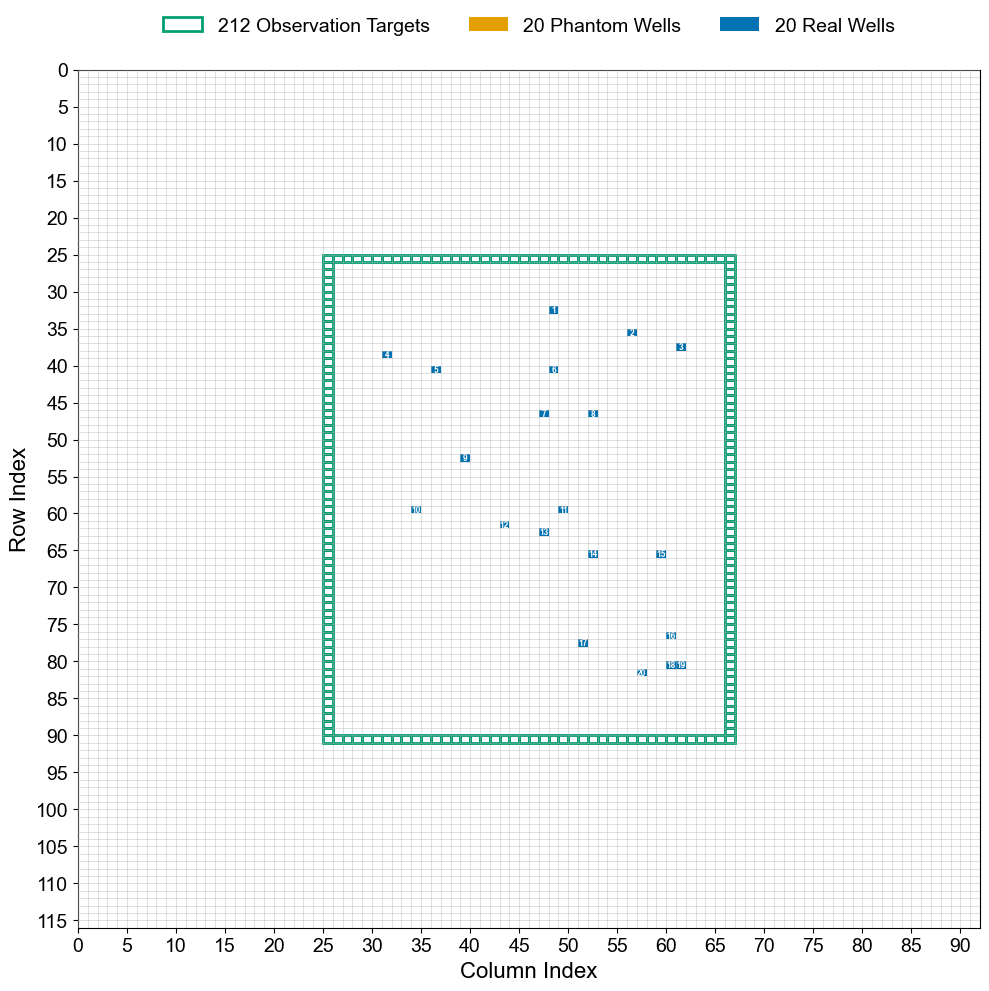

In [45]:
########################
### domain and wells ###
########################

size = 16

# load the real simulation to get grid dimensions
sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws), verbosity_level=0)
gwf = sim_real.get_model("real")
nrow, ncol = gwf.dis.nrow.get_data(), gwf.dis.ncol.get_data()

# load Phantom simulations to get Phantom locations
phantom_coords = []
for folder in [f for f in os.listdir(sims_dir) if f.startswith("phantom_")]:
    try:
        p_sim = flopy.mf6.MFSimulation.load(sim_ws=str(sims_dir/folder), verbosity_level=0, load_only=['wel'])
        gwf_p = p_sim.get_model()
        spd_dict = gwf_p.wel.stress_period_data.get_data()
        
        # target stress period 0 explicitly
        if 0 in spd_dict:
            for entry in spd_dict[0]:  # loop over the recarray records, not keys
                # exrtact elements [1] and [2] from the (layer, row, col) tuple
                r_p = entry['cellid'][1]
                c_p = entry['cellid'][2]
                phantom_coords.append((r_p, c_p))
    except Exception as e:
        # print to catch other issues if they happen
        print(f"Error loading {folder}: {e}")
        continue

sorted_phantoms = sorted(list(set(phantom_coords)))

# get perimeter mask
perimeter_mask = np.zeros((nrow, ncol))
for r, c in set(phantom_coords):
    perimeter_mask[r, c] = 1

# get Real well locations
real_spd = gwf.wel.stress_period_data.get_data()[0]
real_mask = np.zeros((nrow, ncol))
for e in real_spd:
    r, c = e['cellid'][1], e['cellid'][2]
    real_mask[r, c] = 1

# re-generate compliance point cells
margin = int(margin_size)
r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

# top and bottom perimeter cells
for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])

# left and right perimeter cells, excluding corners
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

sorted_cp = sorted(list(set(cp_cells)))

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_facecolor('white')
ax.invert_yaxis()

# base map (empty, just to set extent and aspect)
mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, extent=(0, ncol, 0, nrow))

# plot observation targets
for i, (r, c) in enumerate(sorted_cp):
    rect = patches.Rectangle(
        (c, r), 1, 1, 
        linewidth=2, 
        edgecolor="#009E73",
        facecolor='none',     
        zorder=3
    )
    ax.add_patch(rect)

# plot Phantom wells
for i, (r, c) in enumerate(sorted_phantoms):
    # visual centre of the cell using native row positions
    x_pos = c + 0.5
    y_pos = r + 0.5
    
    rect = patches.Rectangle((c, r), 1, 1, 
                             linewidth=0, facecolor='#E69F00', zorder=2)
    ax.add_patch(rect)
    
    # sequential number label
    ax.text(x_pos, y_pos, str(i + 1), 
            color='white', fontsize=size-10, fontweight='bold',
            ha='center', va='center', zorder=4)

# Real wells
real_spd = gwf.wel.stress_period_data.get_data()[0]
for entry in real_spd:
    _, r_w, c_w = entry['cellid']
    rect = patches.Rectangle((c_w, r_w), 1, 1, linewidth=0, facecolor='#0072B2', zorder=3)
    ax.add_patch(rect)

# grid lines
grid_cfg = {'color': "#B3B3B3", 'lw': 0.5, 'alpha': 0.6, 'zorder': 100} 
for x in range(ncol + 1):
    ax.plot([x, x], [0, nrow], **grid_cfg)
for y in range(nrow + 1):
    ax.plot([0, ncol], [y, y], **grid_cfg)

# labels
ax.set_xlabel("Column Index", fontsize=size)
ax.set_ylabel("Row Index", fontsize=size)

# ticks - simple and un-flipped because invert_yaxis() handles it perfectly
ax.set_xticks(np.arange(0, ncol + 1, 5))
ax.set_yticks(np.arange(0, nrow + 1, 5))

# tick parameters
ax.tick_params(axis='both', which='major', labelsize=size-2)

ax.set_xlim(0, ncol)
# Note: When y-axis is inverted, set_ylim changes order: (top_value, bottom_value)
ax.set_ylim(nrow, 0)

# legend
legend_elements = [
    patches.Patch(facecolor='none', edgecolor="#009E73", linewidth=2, label=f'{len(sorted_cp)} Observation Targets'),
    patches.Patch(facecolor='#E69F00', edgecolor='none', label=f'{len(sorted_phantoms)} Phantom Wells'),
    patches.Patch(facecolor='#0072B2', edgecolor='none', label=f'{len(real_spd)} Real Wells')
]

ax.legend(
    handles=legend_elements, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,            
    facecolor='white', 
    edgecolor='none',   
    framealpha=1, 
    fontsize=size-2
)

plt.tight_layout()
plt.savefig(f"{root}_incdd_domain.svg", dpi=300, bbox_inches='tight')
plt.show()

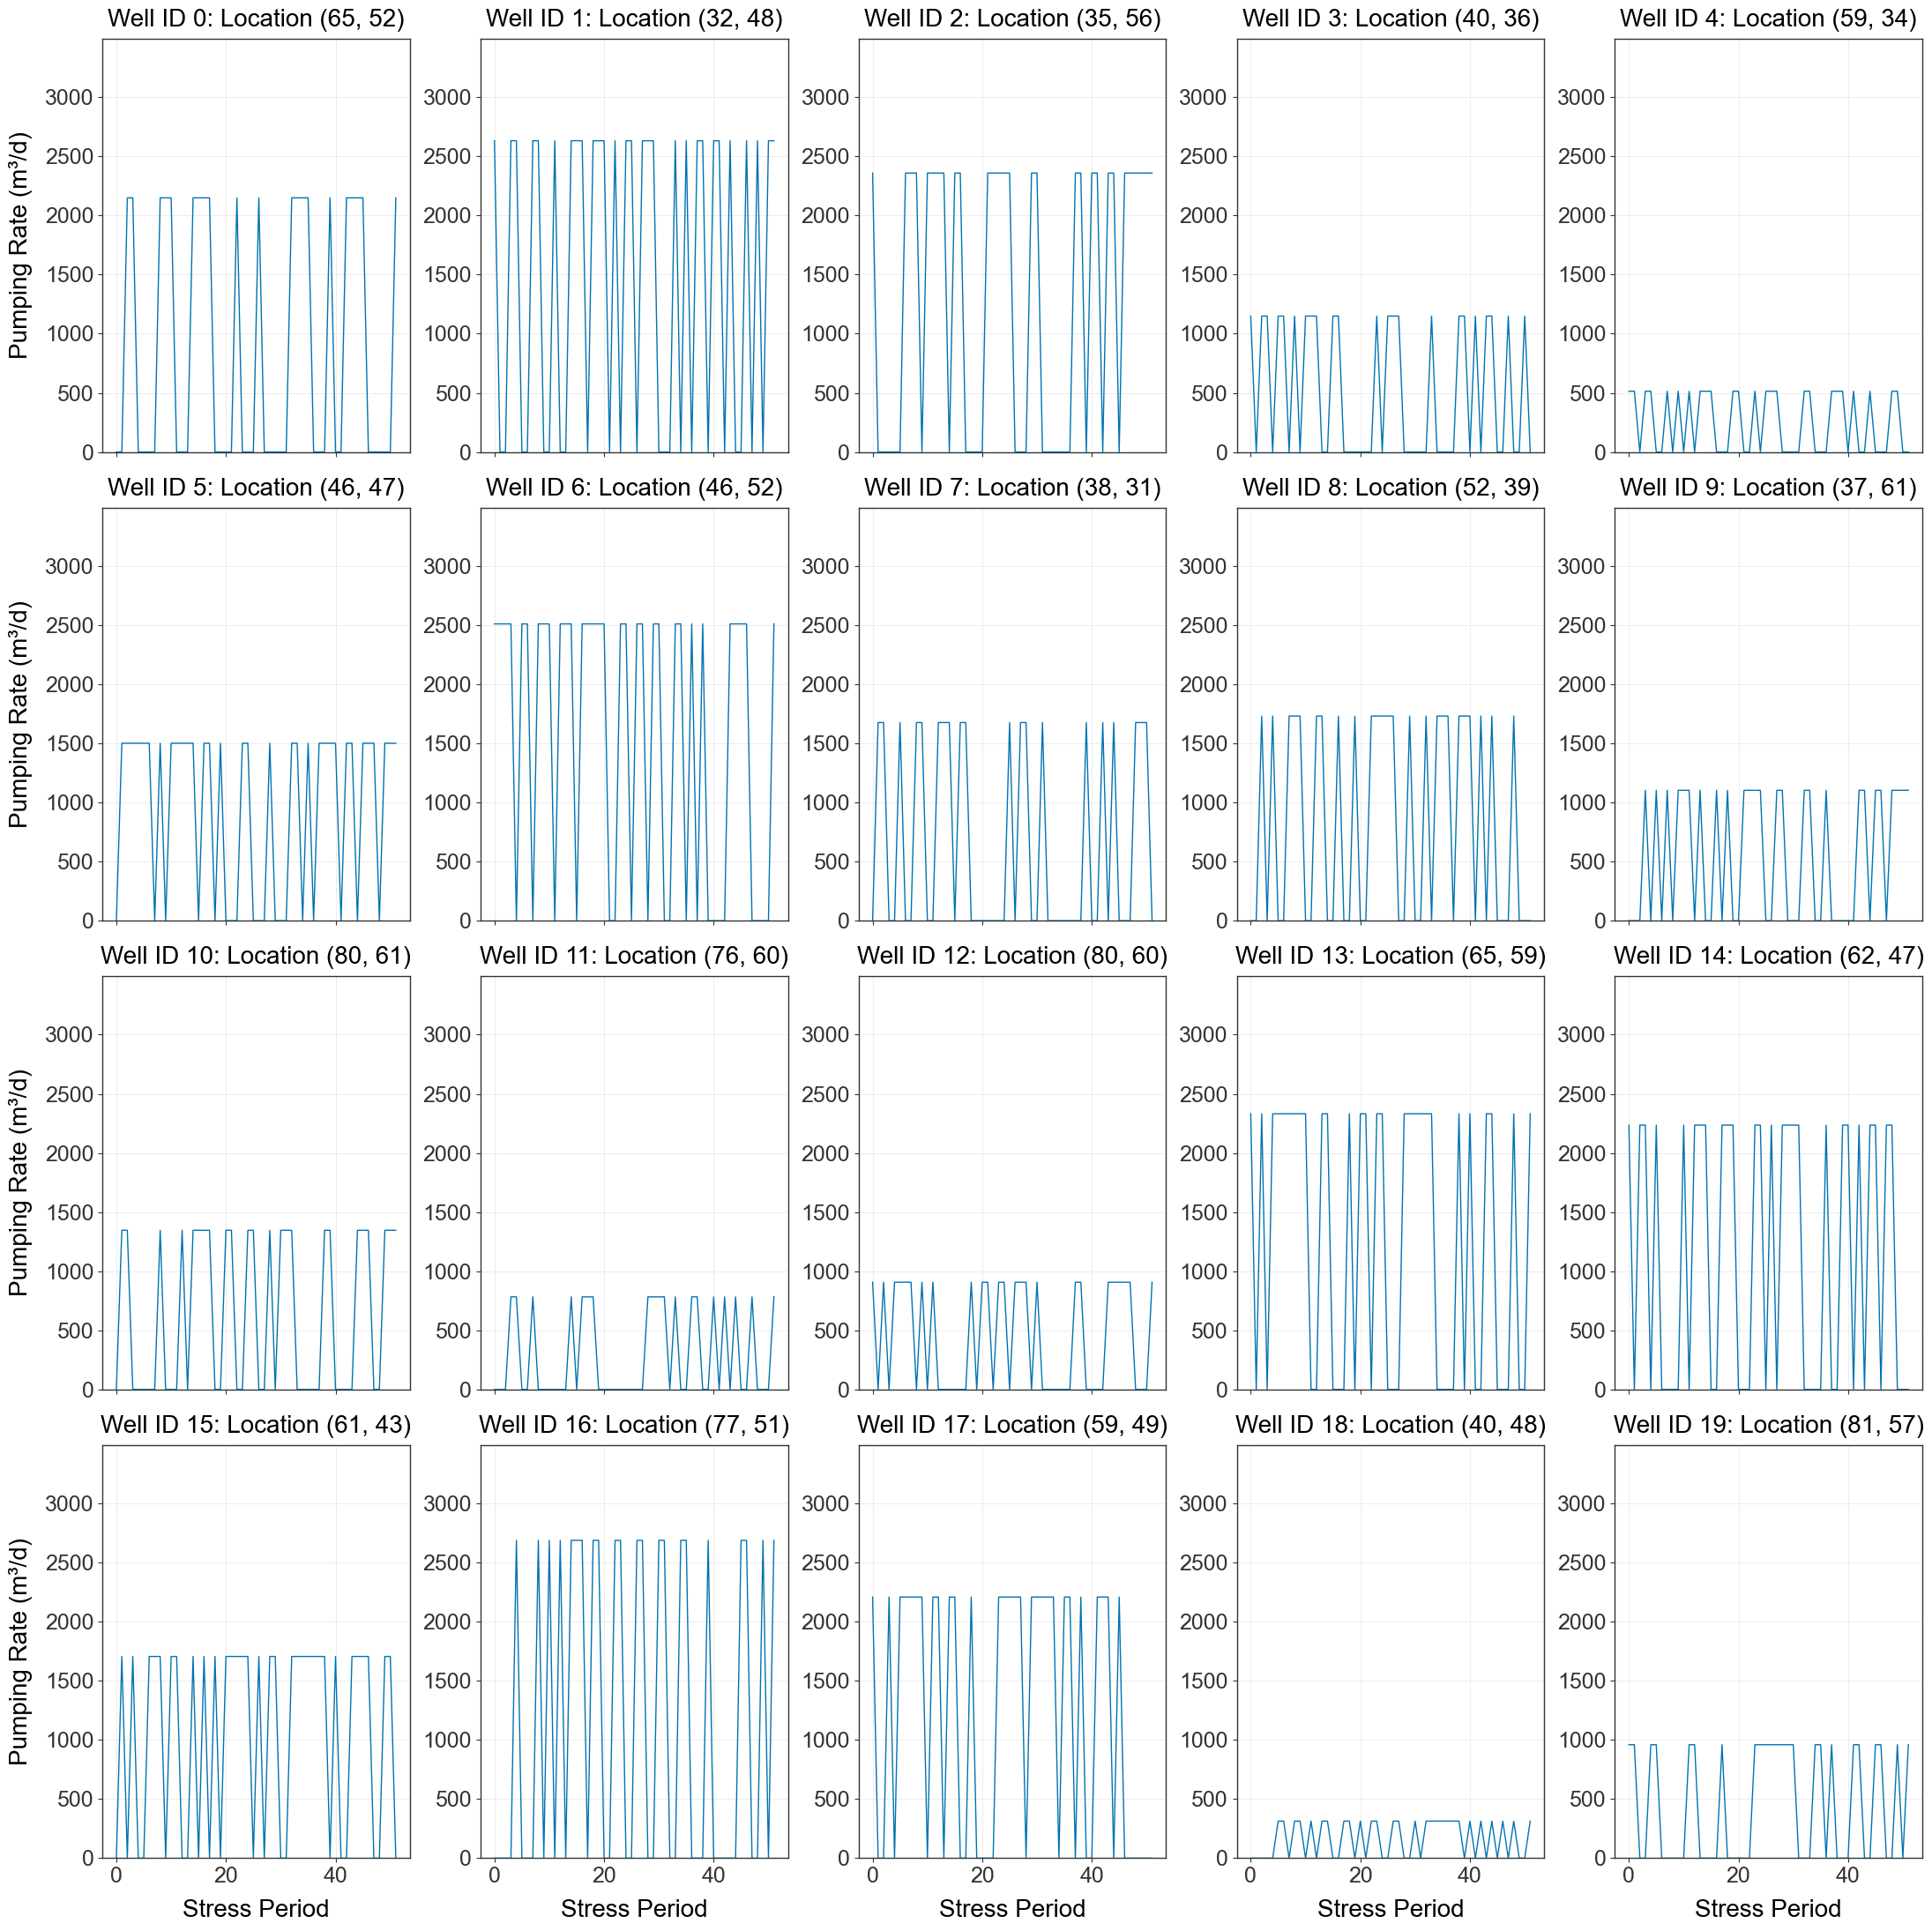

In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# global font size setting for all text elements
size = 24  
mpl.rcParams['font.family'] = 'Arial'

# load data
df_q = pd.read_csv(os.path.join(real_ws, "master_truth.csv"))

# identify the unique wells sorted by ID
unique_wells = df_q.sort_values("well_id")[['well_id', 'r', 'c']].drop_duplicates()
num_wells = len(unique_wells)

# automatically calculate rows to fit all unique wells
num_cols = 5
num_rows = (num_wells + 1) // num_cols

# dynamic canvas sizing: matches the 11x10 base aspect ratio scaled by row count
fig, axes = plt.subplots(num_rows, num_cols, figsize=(22, num_rows * 5.5), sharex=True)
axes = axes.flatten()

# track maximum rate for padding the shared layout scale
global_q_max = df_q['q'].max() if df_q['q'].max() > 0 else 100.0

# plot each well's pumping schedule in its own panel
for i, (_, row) in enumerate(unique_wells.iterrows()):
    ax = axes[i]
    w_id, r, c = int(row.well_id), int(row.r), int(row.c)
    
    # clean canvas initialization matching target style
    ax.set_facecolor('white')
    ax.grid(True, color="#E6E6E6", linestyle="-", linewidth=0.5, zorder=0)
    
    # ensure standard sharp black bounding box frame
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1.0)
    
    # extract and sort columns by Stress Period (sp)
    truth_df_sorted = df_q[df_q.well_id == w_id].sort_values("sp")
    truth_q = truth_df_sorted['q'].values
    stress_periods = truth_df_sorted['sp'].values
    
    # plot pumping rate line using high-visibility consulting blue
    ax.plot(stress_periods, truth_q, color='#0072B2', 
            marker='none', linewidth=1.0, zorder=10)
    
    # panel header formatting (using matching target size hierarchy)
    ax.set_title(f"Well ID {w_id}: Location ({r}, {c})", fontsize=size-4, fontweight='normal', pad=10)
    ax.set_ylim(0, global_q_max * 1.3)  # clean upper breathing bounds
    
    # axis ticks configuration
    ax.tick_params(axis='both', which='major', labelsize=size-6, colors='#333333')
    
    # multi-row label stripping strategy
    if i % num_cols == 0:
        ax.set_ylabel("Pumping Rate (m³/d)", fontsize=size-4, labelpad=10)
    if i >= (num_wells - num_cols):
        ax.set_xlabel("Stress Period", fontsize=size-4, labelpad=10)

#  delete hanging subplots if target well count is odd
for j in range(num_wells, len(axes)):
    fig.delaxes(axes[j])

# export and render
plt.tight_layout()
plt.savefig(f"{root}_pumping_schedules.svg", dpi=300, bbox_inches='tight')
plt.show()


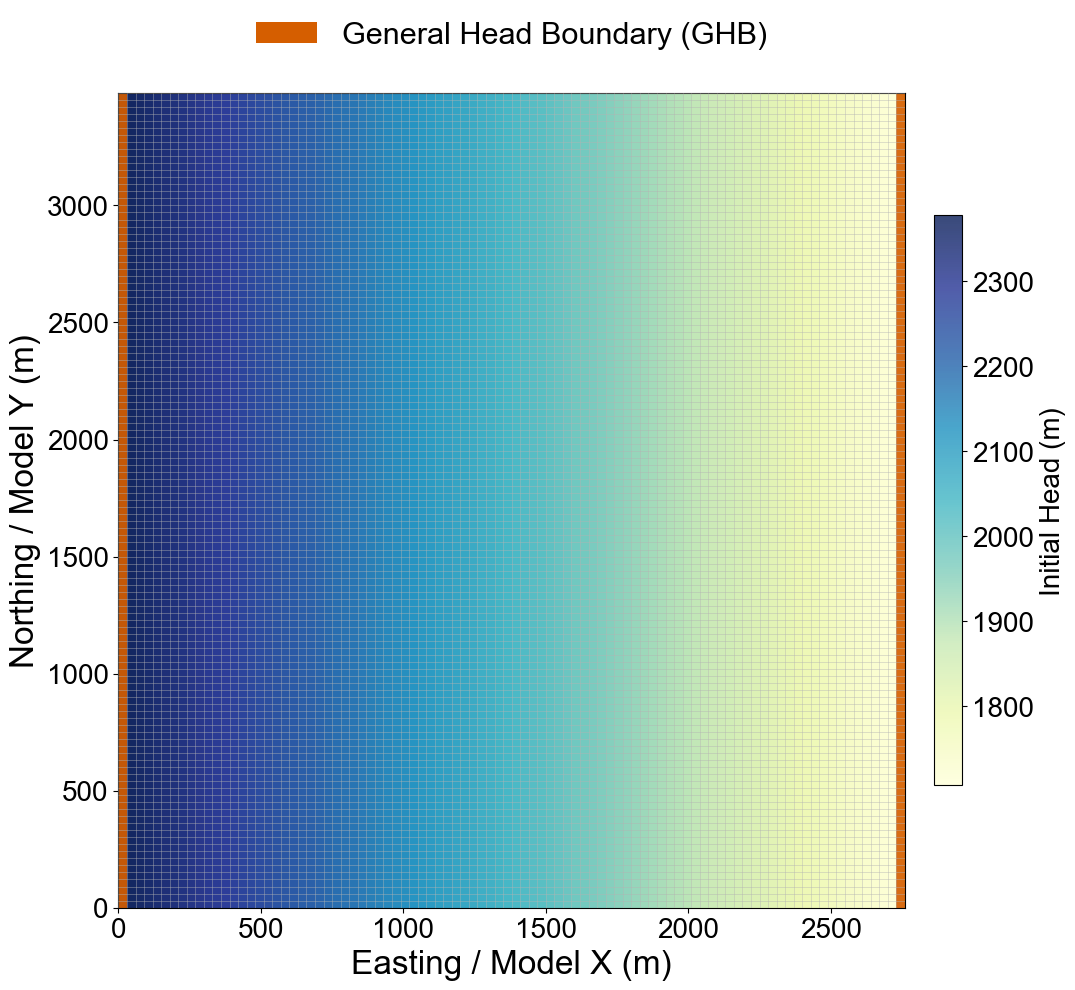

In [50]:
import os
from pathlib import Path
import flopy
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

size = 24
nrow = gwf.dis.nrow.get_data()
ncol = gwf.dis.ncol.get_data()

fig, ax = plt.subplots(1, 1, figsize=(11, 10))
ax.set_facecolor('white')

# initialize MapView with explicit layer=0 to ensure correct spatial referencing and extent
mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)

# pull initial heads and active domain matrix
strt_array = gwf.ic.strt.get_data()[0, :, :]
idomain_array = gwf.dis.idomain.get_data()[0, :, :]

# automatically find min and max only where cells are active (idomain != 0)
active_heads = strt_array[idomain_array != 0]
dynamic_vmin = active_heads.min()
dynamic_vmax = active_heads.max()

# plot background gradient array with dynamic vmin/vmax and masked no-flow cells
strt_masked = np.ma.masked_where(idomain_array == 0, strt_array)
quadmesh = mapview.plot_array(
    strt_masked, 
    cmap="YlGnBu", 
    vmin=dynamic_vmin, 
    vmax=dynamic_vmax, 
    zorder=0, 
    alpha=0.8
)

# overlay grid lines
mapview.plot_grid(colors="#B3B3B3", linewidths=0.5, zorder=100, alpha=0.6)

# setup master legend tracking array
legend_elements = []

# plot No-Flow zones if they exist in idomain
if np.any(idomain_array == 0):
    mapview.plot_ibound(color_noflow='lightgray', zorder=1)
    legend_elements.append(patches.Patch(facecolor='lightgray', edgecolor='#B3B3B3', hatch="//", lw=0.5, label='No-Flow'))

# overlay GHB boundaries
has_ghb = any(p.package_type == "ghb" for p in gwf.packagelist)
if has_ghb:
    mapview.plot_bc(name="GHB", color="#D55E00", alpha=0.7, zorder=1.5)
    legend_elements.append(patches.Patch(facecolor='#D55E00', label='General Head Boundary (GHB)'))

# labels and ticks
ax.set_xlabel("Easting / Model X (m)", fontsize=size)
ax.set_ylabel("Northing / Model Y (m)", fontsize=size)
ax.tick_params(axis='both', which='major', labelsize=size-4)

# colour bar for initial heads with dynamic scaling
cbar = fig.colorbar(quadmesh, ax=ax, shrink=0.7, aspect=20, pad=0.03)
cbar.set_label("Initial Head (m)", fontsize=size-4)
cbar.ax.tick_params(labelsize=size-4)

# legend
if legend_elements:
    ax.legend(
        handles=legend_elements, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=3, 
        facecolor='white', 
        edgecolor='none', 
        framealpha=1, 
        fontsize=size-2
    )

# export and render
plt.tight_layout()
plt.savefig(f"{root}_domain_icbc_only.svg", dpi=300, bbox_inches='tight')
plt.show()

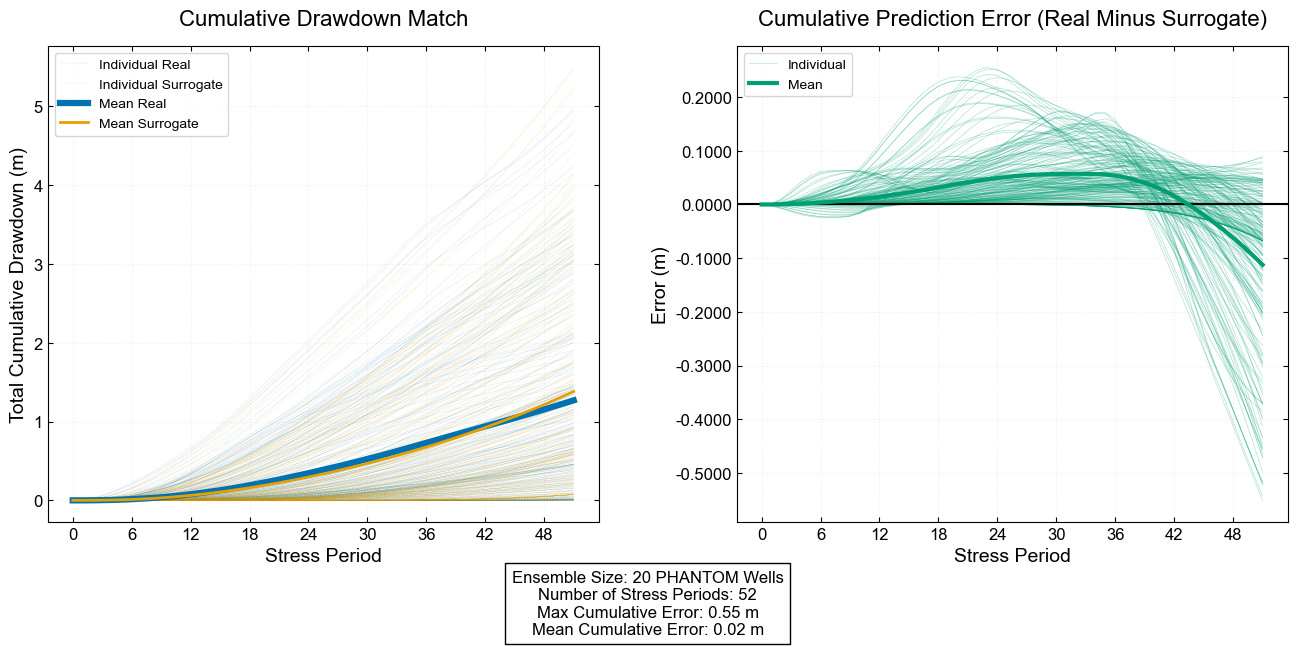

In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

###############
### results ###
###############

results_path = Path("..") / "results"

plot_mode = "cumulative"  # Options: 'incremental' or 'cumulative'

# real_cum: drawdown from the Real simulation 
real_cum = pd.read_csv(results_path / f"{root}_target_drawdown.csv", index_col=0)

# surrogate_cum: drawdown from the Surrogate simulation with the best fit to the Real
surrogate_cum = pd.read_csv(results_path / f"{root}_surrogate_match.csv", index_col=0)

# dynamic processing based on plot mode
if plot_mode == "incremental":
    # fills the first stress period with 0 to safely drop the SP0 initial setup spike
    real_processed = real_cum.diff().fillna(0)
    surrogate_processed = surrogate_cum.diff().fillna(0)
    title_prefix = "Incremental"
    y_label = "Weekly Drawdown Change (m)"
else:
    # use raw total tracking strings directly since they are already cumulative
    real_processed = real_cum
    surrogate_processed = surrogate_cum
    title_prefix = "Cumulative"
    y_label = "Total Cumulative Drawdown (m)"

# calculate error matrix and matching averages
error_df = real_processed - surrogate_processed
real_mean = real_processed.mean(axis=1)
surrogate_mean = surrogate_processed.mean(axis=1)
error_mean = error_df.mean(axis=1)

# set up plot
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.25, bottom=0.2)

size = 16 

# helper function to format axes consistently
def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', 
                   top=True, right=True, labelsize=size-4)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.2, linestyle=':')

# drawdown match plot
for i, col in enumerate(real_processed.columns):
    t_label = 'Individual Real' if i == 0 else ""
    ax1.plot(real_processed.index, real_processed[col], color='#0072B2', alpha=0.7, lw=0.1, label=t_label, linestyle='--', zorder=1)
    
    s_label = 'Individual Surrogate' if i == 0 else ""
    ax1.plot(surrogate_processed.index, surrogate_processed[col], color='#E69F00', alpha=0.7, lw=0.1, label=s_label, linestyle='--', zorder=2)

ax1.plot(real_mean.index, real_mean, color='#0072B2', lw=4.5, label='Mean Real', zorder=5)
ax1.plot(surrogate_mean.index, surrogate_mean, color='#E69F00', lw=2, label='Mean Surrogate', zorder=6)

ax1.set_title(f"{title_prefix} Drawdown Match", fontsize=size, pad=15)
ax1.set_ylabel(y_label, fontsize=size-2)
ax1.set_xlabel("Stress Period", fontsize=size-2)
ax1.legend(loc='upper left', frameon=True, fontsize=size-6)
format_axes(ax1)

# prediction error plot
for i, col in enumerate(error_df.columns):
    label = 'Individual' if i == 0 else ""
    ax2.plot(error_df.index, error_df[col], color='#009E73', alpha=0.3, lw=0.5, label=label, zorder=1)

ax2.plot(error_mean.index, error_mean, color='#009E73', lw=3, label='Mean', zorder=5)
ax2.axhline(0, color='black', lw=1.5, zorder=2)

# --- FIXED: FORCE STANDARD FLOATING POINT TICK FORMATTING ---
# Removed useMathText ScalarFormatter and scilimits=sci settings
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f')) 

ax2.set_title(f"{title_prefix} Prediction Error (Real Minus Surrogate)", fontsize=size, pad=15)
ax2.set_ylabel("Error (m)", fontsize=size-2)
ax2.set_xlabel("Stress Period", fontsize=size-2)
ax2.legend(loc='upper left', fontsize=size-6)
format_axes(ax2)

# --- FIXED: FORMAT STATS WITH PLAIN FLOATS (4 Decimal Places) ---
stats_text = (f"Ensemble Size: {len(phantom_coords)} PHANTOM Wells\n"
              f"Number of Stress Periods: {len(real_cum)}\n"
              f"Max {title_prefix} Error: {error_df.abs().max().max():.2f} m\n"
              f"Mean {title_prefix} Error: {error_df.mean().mean():.2f} m")

fig.text(0.5, 0.04, stats_text, ha='center', fontsize=size-4, 
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='square,pad=0.4'))

plt.savefig(f"{root}_{plot_mode}_results.svg", dpi=300, bbox_inches='tight')
plt.show()

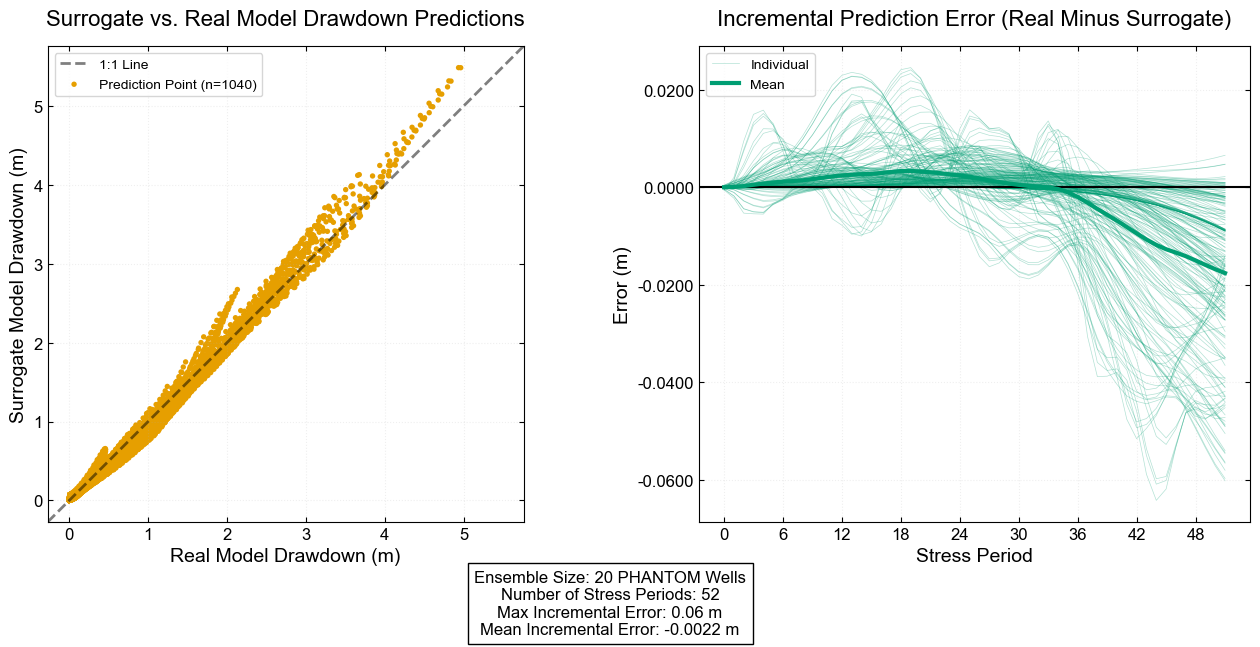

In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches
from pathlib import Path

###############
### results ###
###############

results_path = Path("..") / "results"

# real_cum: drawdown from the Real simulation 
real_cum = pd.read_csv(results_path / f"{root}_target_drawdown.csv", index_col=0)

# surrogate_cum: drawdown from the Surrogate simulation with the best fit to the Real
surrogate_cum = pd.read_csv(results_path / f"{root}_surrogate_match.csv", index_col=0)

# calculate incremental drawdown and error
real_inc = real_cum.diff().fillna(real_cum.iloc[0])
surrogate_inc = surrogate_cum.diff().fillna(surrogate_cum.iloc[0])
error_inc_df = real_inc - surrogate_inc

# calculate means for plotting
real_inc_mean = real_inc.mean(axis=1)
surrogate_inc_mean = surrogate_inc.mean(axis=1)
error_inc_mean = error_inc_df.mean(axis=1)

# set up plot
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.25, bottom=0.2)

# global font size setting for all text elements
size = 16 

# helper function to format axes consistently
def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', 
                   top=True, right=True, labelsize=size-4)
    # Force integer ticks for Stress Periods
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.2, linestyle=':')

# plot scatter of cumulative drawdown predictions with a 1:1 reference line
vals_all = np.concatenate([real_cum.values.flatten(), surrogate_cum.values.flatten()])
vmin, vmax = vals_all.min(), vals_all.max()
buffer = (vmax - vmin) * 0.05
common_lims = (vmin - buffer, vmax + buffer)

# common limits for x and y axes
ax1.set_xlim(common_lims)
ax1.set_ylim(common_lims)

# 1:1 line
ax1.plot(common_lims, common_lims, color="#000000", alpha=0.5, linestyle='--', lw=2, label='1:1 Line', zorder=3)
ax1.scatter(real_cum, surrogate_cum, color='#E69F00', s=15, edgecolors='none', label=f'Prediction Point (n={(len(real_cum)*len(phantom_coords))})', zorder=1)

# square aspect ratio
ax1.set_aspect('equal', adjustable='box')

#  match master templates
ax1.set_title("Surrogate vs. Real Model Drawdown Predictions", fontsize=size, pad=15)
ax1.set_ylabel("Surrogate Model Drawdown (m)", fontsize=size-2)
ax1.set_xlabel("Real Model Drawdown (m)", fontsize=size-2)
ax1.legend(loc='upper left', fontsize=size-6)

# plot incremental error
for i, col in enumerate(error_inc_df.columns):
    label = 'Individual' if i == 0 else ""
    ax2.plot(error_inc_df.index, error_inc_df[col], color='#009E73', alpha=0.3, lw=0.5, label=label, zorder=1)

ax2.plot(error_inc_mean.index, error_inc_mean, color='#009E73', lw=3, label='Mean', zorder=5)
ax2.axhline(0, color='black', lw=1.5, zorder=2)

# strip scientific notation and force plain decimals with 4 decimal places for error values
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f')) 

ax2.set_title("Incremental Prediction Error (Real Minus Surrogate)", fontsize=size, pad=15)
ax2.set_ylabel("Error (m)", fontsize=size-2)
ax2.set_xlabel("Stress Period", fontsize=size-2)
ax2.legend(loc='upper left', fontsize=size-6)

# format axes per template function
format_axes(ax1)
format_axes(ax2)

# format stats with plain floats (4 decimal places) and re-phrase to match incremental context
stats_text = (f"Ensemble Size: {len(phantom_coords)} PHANTOM Wells\n"
              f"Number of Stress Periods: {len(real_cum)}\n"
              f"Max Incremental Error: {error_inc_df.abs().max().max():.2f} m\n"
              f"Mean Incremental Error: {error_inc_df.mean().mean():.4f} m")

fig.text(0.5, 0.04, stats_text, ha='center', fontsize=size-4, 
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='square,pad=0.4'))

plt.savefig(f"{root}_incdd_results2.svg", dpi=300, bbox_inches='tight')
plt.show()
